In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define dataset pa
DATA_DIR = '/kaggle/input/datasets/akrashnoor/hematology-image-classification-dataset-hicd' 

# We will look for the exact subfolder containing the class folders
# If the dataset has nested folders, this dynamically finds the one with the images
for root, dirs, files in os.walk(DATA_DIR):
    if len(dirs) > 0 and len(files) > 0:
        DATA_DIR = root
        break

Using device: cuda


In [3]:
# Define standard transforms for pre-trained models
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load entire dataset
try:
    full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=transform)
    classes = full_dataset.classes
    num_classes = len(classes)
    print(f"Classes found ({num_classes}): {classes}")

    # Split into 80% Train, 20% Test
    train_size = int(0.8 * len(full_dataset))
    test_size = len(full_dataset) - train_size
    train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

    # Create DataLoaders
    batch_size = 32
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Please verify the DATA_DIR path matches the Kaggle input directory structure.")

Classes found (4): ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']


In [4]:
def build_model(model_name, num_classes):
    """Loads a pre-trained model and modifies the final classification layer."""
    if model_name == 'MobileNetV2':
        model = models.mobilenet_v2(pretrained=True)
        # Freeze base layers
        for param in model.parameters(): param.requires_grad = False
        # Add custom output layer
        model.classifier[1] = nn.Linear(model.last_channel, num_classes)
        
    elif model_name == 'EfficientNet-B0':
        model = models.efficientnet_b0(pretrained=True)
        for param in model.parameters(): param.requires_grad = False
        model.classifier[1] = nn.Linear(1280, num_classes)
        
    elif model_name == 'ShuffleNetV2':
        model = models.shufflenet_v2_x1_0(pretrained=True)
        for param in model.parameters(): param.requires_grad = False
        model.fc = nn.Linear(1024, num_classes)
        
    return model.to(device)

In [5]:
def train_model(model, train_loader, criterion, optimizer, epochs=5):
    """Trains the model for a specified number of epochs."""
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")

def evaluate_and_time_model(model, test_loader):
    """Evaluates the model and calculates metrics + inference time."""
    model.eval()
    all_preds = []
    all_labels = []
    
    # Warm-up (Important for accurate GPU timing)
    dummy_input = torch.randn(1, 3, 224, 224).to(device)
    with torch.no_grad():
        _ = model(dummy_input)

    # Start Inference Timing
    start_time = time.perf_counter()
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    end_time = time.perf_counter()
    
    # Calculate Metrics
    total_time = end_time - start_time
    avg_inference_time = (total_time / len(test_loader.dataset)) * 1000 # in milliseconds
    
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    return acc, prec, rec, avg_inference_time

In [6]:
import psutil
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, f1_score, classification_report, matthews_corrcoef
from sklearn.preprocessing import label_binarize
from itertools import cycle

In [7]:
# --- 1. Memory Tracking ---
def get_memory_usage():
    """Returns RAM and GPU VRAM usage in GB."""
    ram = psutil.virtual_memory().used / (1024**3)
    vram = torch.cuda.memory_allocated() / (1024**3) if torch.cuda.is_available() else 0
    return ram, vram

# --- 2. PyTorch Forward Hook Setup ---
activation = {}
def get_activation(name):
    """Hook to capture the output of a specific layer."""
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

def attach_hook(model, arch_name):
    """Attaches a hook to a late convolutional layer to see what the model is 'looking' at."""
    if arch_name == 'MobileNetV2':
        # Hook into the last Conv layer before pooling
        model.features[-1].register_forward_hook(get_activation('final_conv'))
    elif arch_name == 'EfficientNet-B0':
        model.features[-1].register_forward_hook(get_activation('final_conv'))
    elif arch_name == 'ShuffleNetV2':
        model.conv5.register_forward_hook(get_activation('final_conv'))

In [8]:
def train_and_eval_model(model, train_loader, test_loader, criterion, optimizer, epochs=5):
    train_losses = []
    
    # Track Memory Before Training
    start_ram, start_vram = get_memory_usage()
    print(f"Initial Memory - RAM: {start_ram:.2f} GB | VRAM: {start_vram:.2f} GB")

    # --- TRAINING PHASE ---
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        avg_loss = running_loss/len(train_loader)
        train_losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

    # Track Memory After Training
    end_ram, end_vram = get_memory_usage()
    print(f"Post-Training Memory - RAM: {end_ram:.2f} GB | VRAM: {end_vram:.2f} GB")
    memory_diff = {'RAM_GB': end_ram - start_ram, 'VRAM_GB': end_vram - start_vram}

    # --- EVALUATION PHASE ---
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            
            # Get probabilities for ROC curve using Softmax
            probs = torch.nn.functional.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().numpy())
            
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # Calculate Extended Metrics
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    mcc = matthews_corrcoef(all_labels, all_preds)
    
    metrics = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'MCC': mcc}
    
    return train_losses, all_labels, all_preds, np.array(all_probs), metrics, memory_diff

In [9]:
def plot_model_diagnostics(arch_name, train_losses, y_true, y_pred, y_probs, class_names):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f"Diagnostics for {arch_name}", fontsize=16, fontweight='bold')

    # 1. Loss Curve
    axes[0].plot(range(1, len(train_losses)+1), train_losses, marker='o', color='b')
    axes[0].set_title('Training Loss per Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True)

    # 2. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], 
                xticklabels=class_names, yticklabels=class_names)
    axes[1].set_title('Confusion Matrix')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')

    # 3. Multi-class ROC-AUC (One-vs-Rest)
    y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
    n_classes = y_true_bin.shape[1]
    
    colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan'])
    for i, color in zip(range(n_classes), colors):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        axes[2].plot(fpr, tpr, color=color, lw=2,
                     label=f'Class {class_names[i]} (AUC = {roc_auc:.2f})')
        
    axes[2].plot([0, 1], [0, 1], 'k--', lw=2)
    axes[2].set_xlim([0.0, 1.0])
    axes[2].set_ylim([0.0, 1.05])
    axes[2].set_title('ROC Curve')
    axes[2].set_xlabel('False Positive Rate')
    axes[2].set_ylabel('True Positive Rate')
    axes[2].legend(loc="lower right", fontsize=8)

    plt.tight_layout()
    plt.show()

    # Print Classification Report
    print(f"\nClassification Report for {arch_name}:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

In [10]:
def visualize_activations(model, arch_name, sample_image_tensor, sample_image_numpy):
    """Passes an image through the model and plots the feature map from the hook."""
    model.eval()
    with torch.no_grad():
        _ = model(sample_image_tensor.unsqueeze(0).to(device))
        
    # Get the captured feature map from our hook
    act = activation['final_conv'].squeeze().cpu()
    
    # Average the channels to get a single activation heatmap
    heatmap = torch.mean(act, dim=0).numpy()
    
    # Normalize for visualization
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # Un-normalize the original image for plotting
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_display = std * sample_image_numpy.transpose((1, 2, 0)) + mean
    img_display = np.clip(img_display, 0, 1)

    axes[0].imshow(img_display)
    axes[0].set_title(f"Original Image")
    axes[0].axis('off')

    axes[1].imshow(heatmap, cmap='viridis')
    axes[1].set_title(f"{arch_name} Final Conv Activation")
    axes[1].axis('off')

    plt.show()

In [11]:
import tracemalloc
import time

def profile_cpu_edge_inference(model, test_loader):
    """Forces the model to CPU and profiles exact peak RAM for a single frame."""
    
    # 1. Force model to CPU for the simulation
    cpu_device = torch.device("cpu")
    model = model.to(cpu_device)
    model.eval()
    
    # Grab a single image tensor to perfectly simulate a Raspberry Pi frame
    inputs, _ = next(iter(test_loader))
    single_input = inputs[0:1].to(cpu_device) 
    
    # 2. Warm-up (Gets the CPU cache ready)
    with torch.no_grad():
        for _ in range(3):
            _ = model(single_input)
            
    # 3. Start Tracking Memory
    tracemalloc.start()
    start_time = time.perf_counter()
    
    # 4. THE INFERENCE PASS (Strictly on CPU)
    with torch.no_grad():
        _ = model(single_input)
        
    end_time = time.perf_counter()
    
    # 5. Extract Stats
    current_ram, peak_ram = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    
    peak_ram_mb = peak_ram / (1024 * 1024)
    inference_time_ms = (end_time - start_time) * 1000
    
    print(f"--- CPU Edge Simulation (Raspberry Pi) ---")
    print(f"Inference Time: {inference_time_ms:.2f} ms")
    print(f"Peak CPU RAM Spiked: {peak_ram_mb:.4f} MB")
    
    # Move model back to your original device (GPU) so you don't break subsequent code
    model = model.to(device)
    
    return peak_ram_mb, inference_time_ms


🚀 INITIALIZING PIPELINE FOR: MobileNetV2
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 120MB/s]



--- Training & Evaluation Phase ---
Initial Memory - RAM: 1.42 GB | VRAM: 0.01 GB
Epoch 1/10 - Loss: 0.9695
Epoch 2/10 - Loss: 0.7267
Epoch 3/10 - Loss: 0.6596
Epoch 4/10 - Loss: 0.6288
Epoch 5/10 - Loss: 0.6126
Epoch 6/10 - Loss: 0.5815
Epoch 7/10 - Loss: 0.5702
Epoch 8/10 - Loss: 0.5524
Epoch 9/10 - Loss: 0.5355
Epoch 10/10 - Loss: 0.5378
Post-Training Memory - RAM: 1.69 GB | VRAM: 0.04 GB

--- Simulating Edge Device Inference ---
--- CPU Edge Simulation (Raspberry Pi) ---
Inference Time: 33.73 ms
Peak CPU RAM Spiked: 0.0027 MB

--- Plotting Diagnostics Phase ---


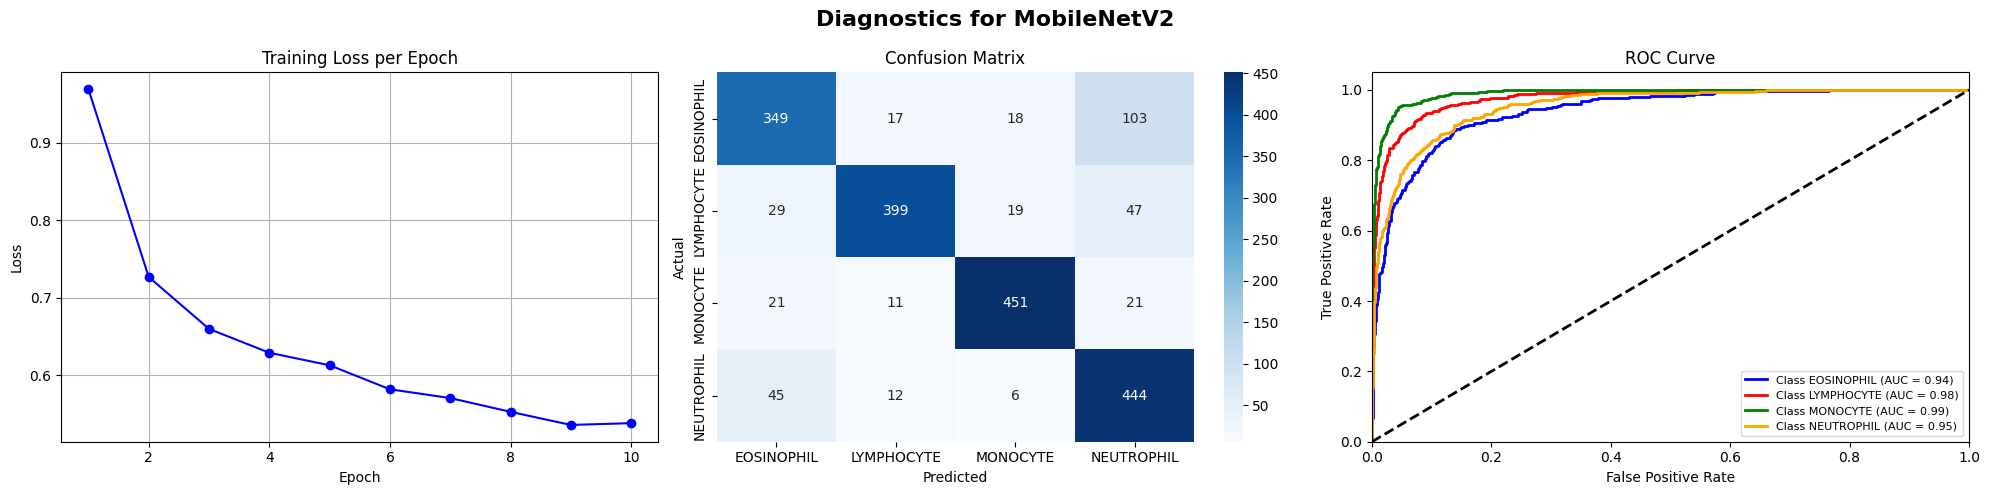


Classification Report for MobileNetV2:

              precision    recall  f1-score   support

  EOSINOPHIL       0.79      0.72      0.75       487
  LYMPHOCYTE       0.91      0.81      0.86       494
    MONOCYTE       0.91      0.89      0.90       504
  NEUTROPHIL       0.72      0.88      0.79       507

    accuracy                           0.82      1992
   macro avg       0.83      0.82      0.83      1992
weighted avg       0.83      0.82      0.83      1992


--- Visualizing Feature Activations for MobileNetV2 ---


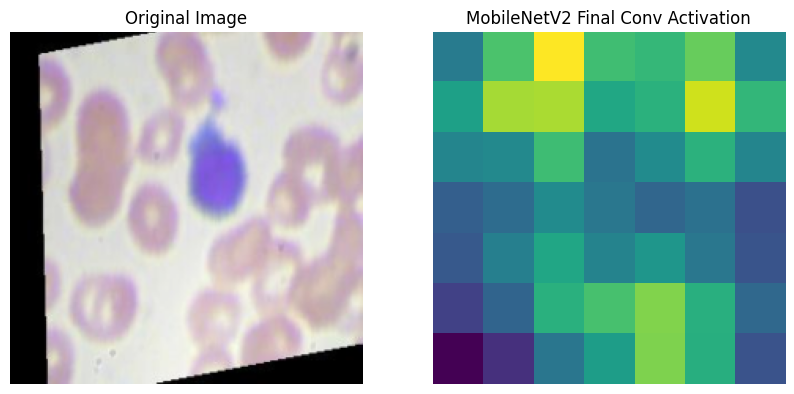


🚀 INITIALIZING PIPELINE FOR: EfficientNet-B0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 120MB/s] 



--- Training & Evaluation Phase ---
Initial Memory - RAM: 1.81 GB | VRAM: 0.03 GB
Epoch 1/10 - Loss: 0.9670
Epoch 2/10 - Loss: 0.7047
Epoch 3/10 - Loss: 0.6119
Epoch 4/10 - Loss: 0.5540
Epoch 5/10 - Loss: 0.5341
Epoch 6/10 - Loss: 0.5138
Epoch 7/10 - Loss: 0.5003
Epoch 8/10 - Loss: 0.4803
Epoch 9/10 - Loss: 0.4504
Epoch 10/10 - Loss: 0.4611
Post-Training Memory - RAM: 1.82 GB | VRAM: 0.05 GB

--- Simulating Edge Device Inference ---
--- CPU Edge Simulation (Raspberry Pi) ---
Inference Time: 47.36 ms
Peak CPU RAM Spiked: 0.0032 MB

--- Plotting Diagnostics Phase ---


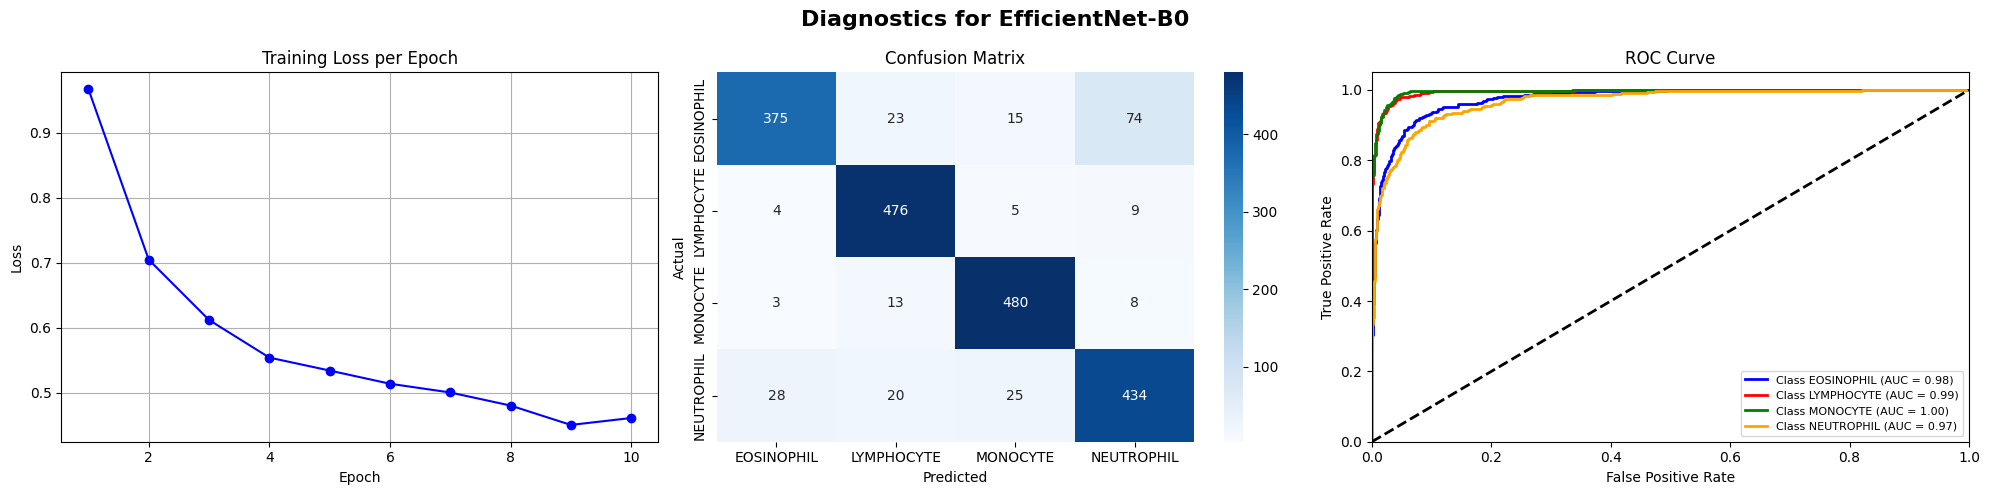


Classification Report for EfficientNet-B0:

              precision    recall  f1-score   support

  EOSINOPHIL       0.91      0.77      0.84       487
  LYMPHOCYTE       0.89      0.96      0.93       494
    MONOCYTE       0.91      0.95      0.93       504
  NEUTROPHIL       0.83      0.86      0.84       507

    accuracy                           0.89      1992
   macro avg       0.89      0.89      0.88      1992
weighted avg       0.89      0.89      0.88      1992


--- Visualizing Feature Activations for EfficientNet-B0 ---


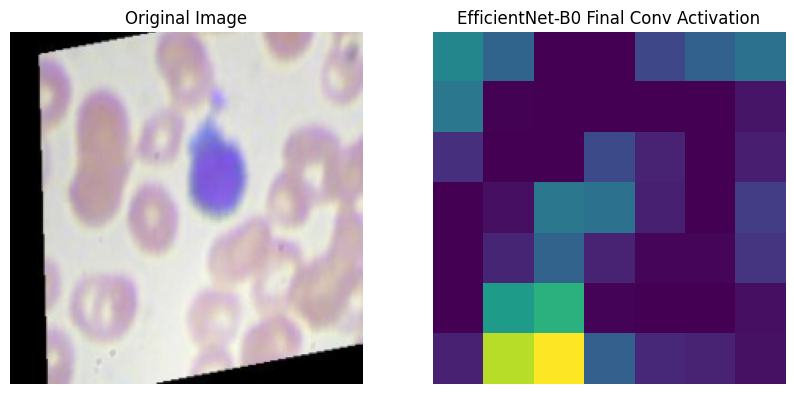


🚀 INITIALIZING PIPELINE FOR: ShuffleNetV2
Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth


100%|██████████| 8.79M/8.79M [00:00<00:00, 92.1MB/s]


--- Training & Evaluation Phase ---
Initial Memory - RAM: 1.88 GB | VRAM: 0.02 GB


Epoch 1/10 - Loss: 1.3278
Epoch 2/10 - Loss: 1.2231
Epoch 3/10 - Loss: 1.1442
Epoch 4/10 - Loss: 1.0826
Epoch 5/10 - Loss: 1.0304
Epoch 6/10 - Loss: 0.9873
Epoch 7/10 - Loss: 0.9507
Epoch 8/10 - Loss: 0.9147
Epoch 9/10 - Loss: 0.8845
Epoch 10/10 - Loss: 0.8611
Post-Training Memory - RAM: 1.89 GB | VRAM: 0.04 GB

--- Simulating Edge Device Inference ---
--- CPU Edge Simulation (Raspberry Pi) ---
Inference Time: 28.51 ms
Peak CPU RAM Spiked: 0.0027 MB

--- Plotting Diagnostics Phase ---


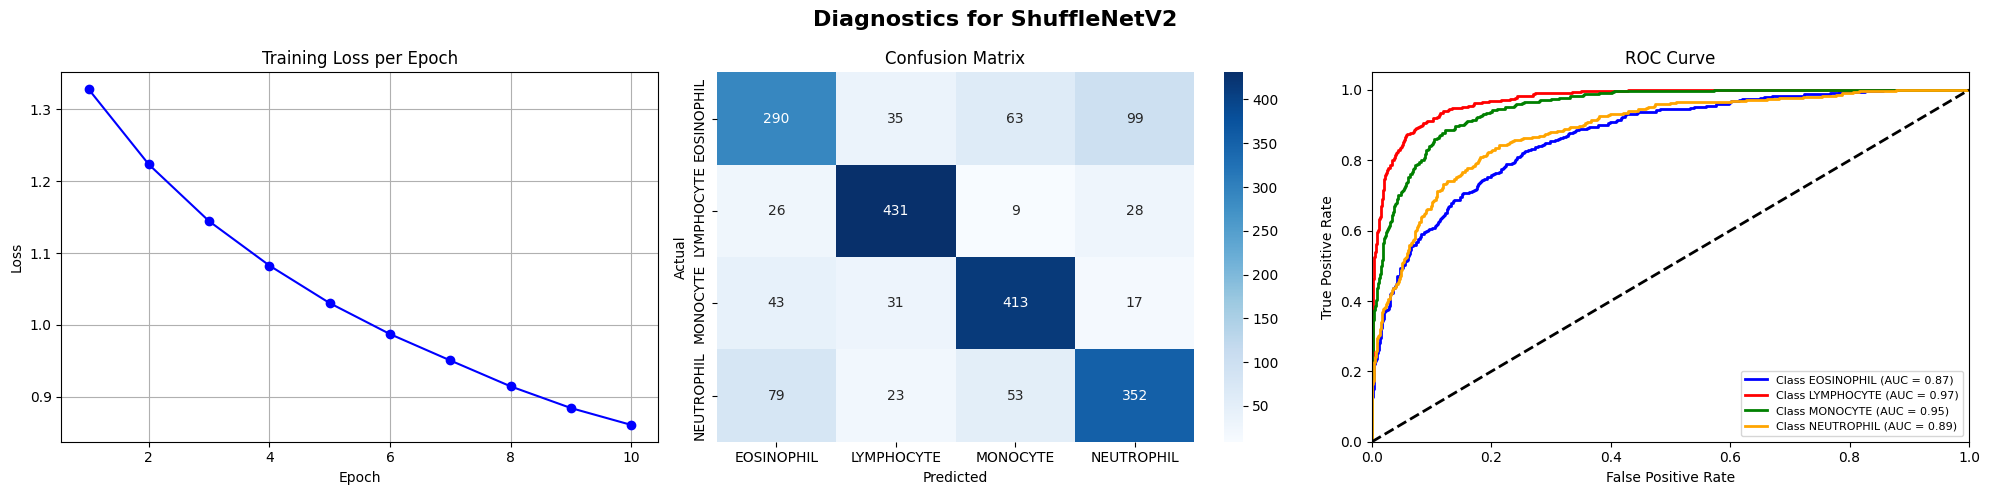


Classification Report for ShuffleNetV2:

              precision    recall  f1-score   support

  EOSINOPHIL       0.66      0.60      0.63       487
  LYMPHOCYTE       0.83      0.87      0.85       494
    MONOCYTE       0.77      0.82      0.79       504
  NEUTROPHIL       0.71      0.69      0.70       507

    accuracy                           0.75      1992
   macro avg       0.74      0.75      0.74      1992
weighted avg       0.74      0.75      0.74      1992


--- Visualizing Feature Activations for ShuffleNetV2 ---


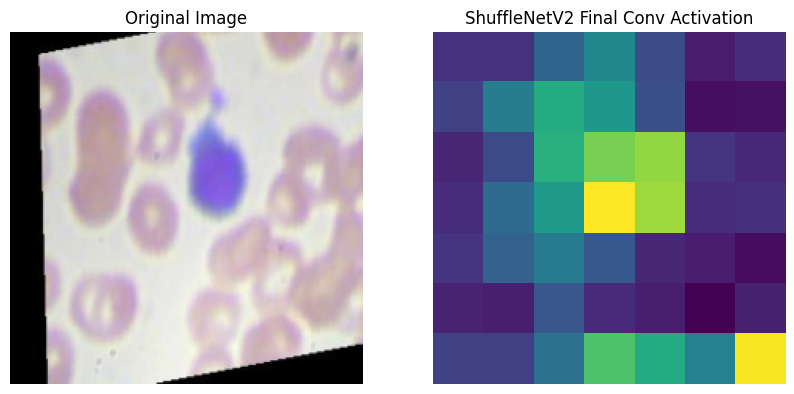



********************************************************************************
FINAL CROSS-COMPARISON RESULTS
********************************************************************************


,Model,Accuracy (%),F1-Score,MCC,RAM Cost (GB),VRAM Cost (GB)
0,MobileNetV2,82.48,0.8255,0.7684,0.2678,0.0332
1,EfficientNet-B0,88.60,0.8846,0.8492,0.0076,0.0167
2,ShuffleNetV2,74.60,0.7433,0.6617,0.0102,0.0163


In [13]:
# List of models to evaluate
architectures = ['MobileNetV2', 'EfficientNet-B0', 'ShuffleNetV2']
results = []
EPOCHS = 10

criterion = nn.CrossEntropyLoss()

# Grab a single sample for the activation map visualization later
sample_inputs, _ = next(iter(test_loader))
single_image_tensor = sample_inputs[0]
single_image_numpy = single_image_tensor.numpy()

for arch in architectures:
    print(f"\n{'='*60}")
    print(f"🚀 INITIALIZING PIPELINE FOR: {arch}")
    print(f"{'='*60}")
    
    # 1. Build Model
    model = build_model(arch, num_classes)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
    
    # 2. Train & Evaluate (Memory tracked inside)
    print("\n--- Training & Evaluation Phase ---")
    train_losses, y_true, y_pred, y_probs, metrics, mem_diff = train_and_eval_model(
        model, train_loader, test_loader, criterion, optimizer, epochs=EPOCHS
    )

    print("\n--- Simulating Edge Device Inference ---")
    peak_edge_ram, edge_time_ms = profile_cpu_edge_inference(model, test_loader)
    
    # 3. Store Results
    results.append({
        'Model': arch,
        'Accuracy (%)': round(metrics['Accuracy'] * 100, 2),
        'F1-Score': round(metrics['F1-Score'], 4),
        'MCC': round(metrics['MCC'], 4),
        'RAM Cost (GB)': round(mem_diff['RAM_GB'], 4),
        'VRAM Cost (GB)': round(mem_diff['VRAM_GB'], 4)
    })
    
    # 4. Generate All Diagnostics (Loss, Confusion, ROC, Classification Report)
    print("\n--- Plotting Diagnostics Phase ---")
    plot_model_diagnostics(arch, train_losses, y_true, y_pred, y_probs, classes)
    
    # 5. Visualize Activations (The Hook)
    print(f"\n--- Visualizing Feature Activations for {arch} ---")
    attach_hook(model, arch) 
    visualize_activations(model, arch, single_image_tensor, single_image_numpy)
    
# Create a comparative DataFrame
df_results = pd.DataFrame(results)

# Display final comparison
print("\n\n" + "*"*80)
print("FINAL CROSS-COMPARISON RESULTS")
print("*"*80)
display(df_results)

Generating Overlay: Sample 0 - Model MobileNetV2...
Generating Overlay: Sample 0 - Model EfficientNet-B0...
Generating Overlay: Sample 0 - Model ShuffleNetV2...
Generating Overlay: Sample 5 - Model MobileNetV2...
Generating Overlay: Sample 5 - Model EfficientNet-B0...
Generating Overlay: Sample 5 - Model ShuffleNetV2...
Generating Overlay: Sample 10 - Model MobileNetV2...
Generating Overlay: Sample 10 - Model EfficientNet-B0...
Generating Overlay: Sample 10 - Model ShuffleNetV2...
Generating Overlay: Sample 15 - Model MobileNetV2...
Generating Overlay: Sample 15 - Model EfficientNet-B0...
Generating Overlay: Sample 15 - Model ShuffleNetV2...
Generating Overlay: Sample 20 - Model MobileNetV2...
Generating Overlay: Sample 20 - Model EfficientNet-B0...
Generating Overlay: Sample 20 - Model ShuffleNetV2...

Visualization complete. Compare which features (nucleus vs granules) each model prioritizes!


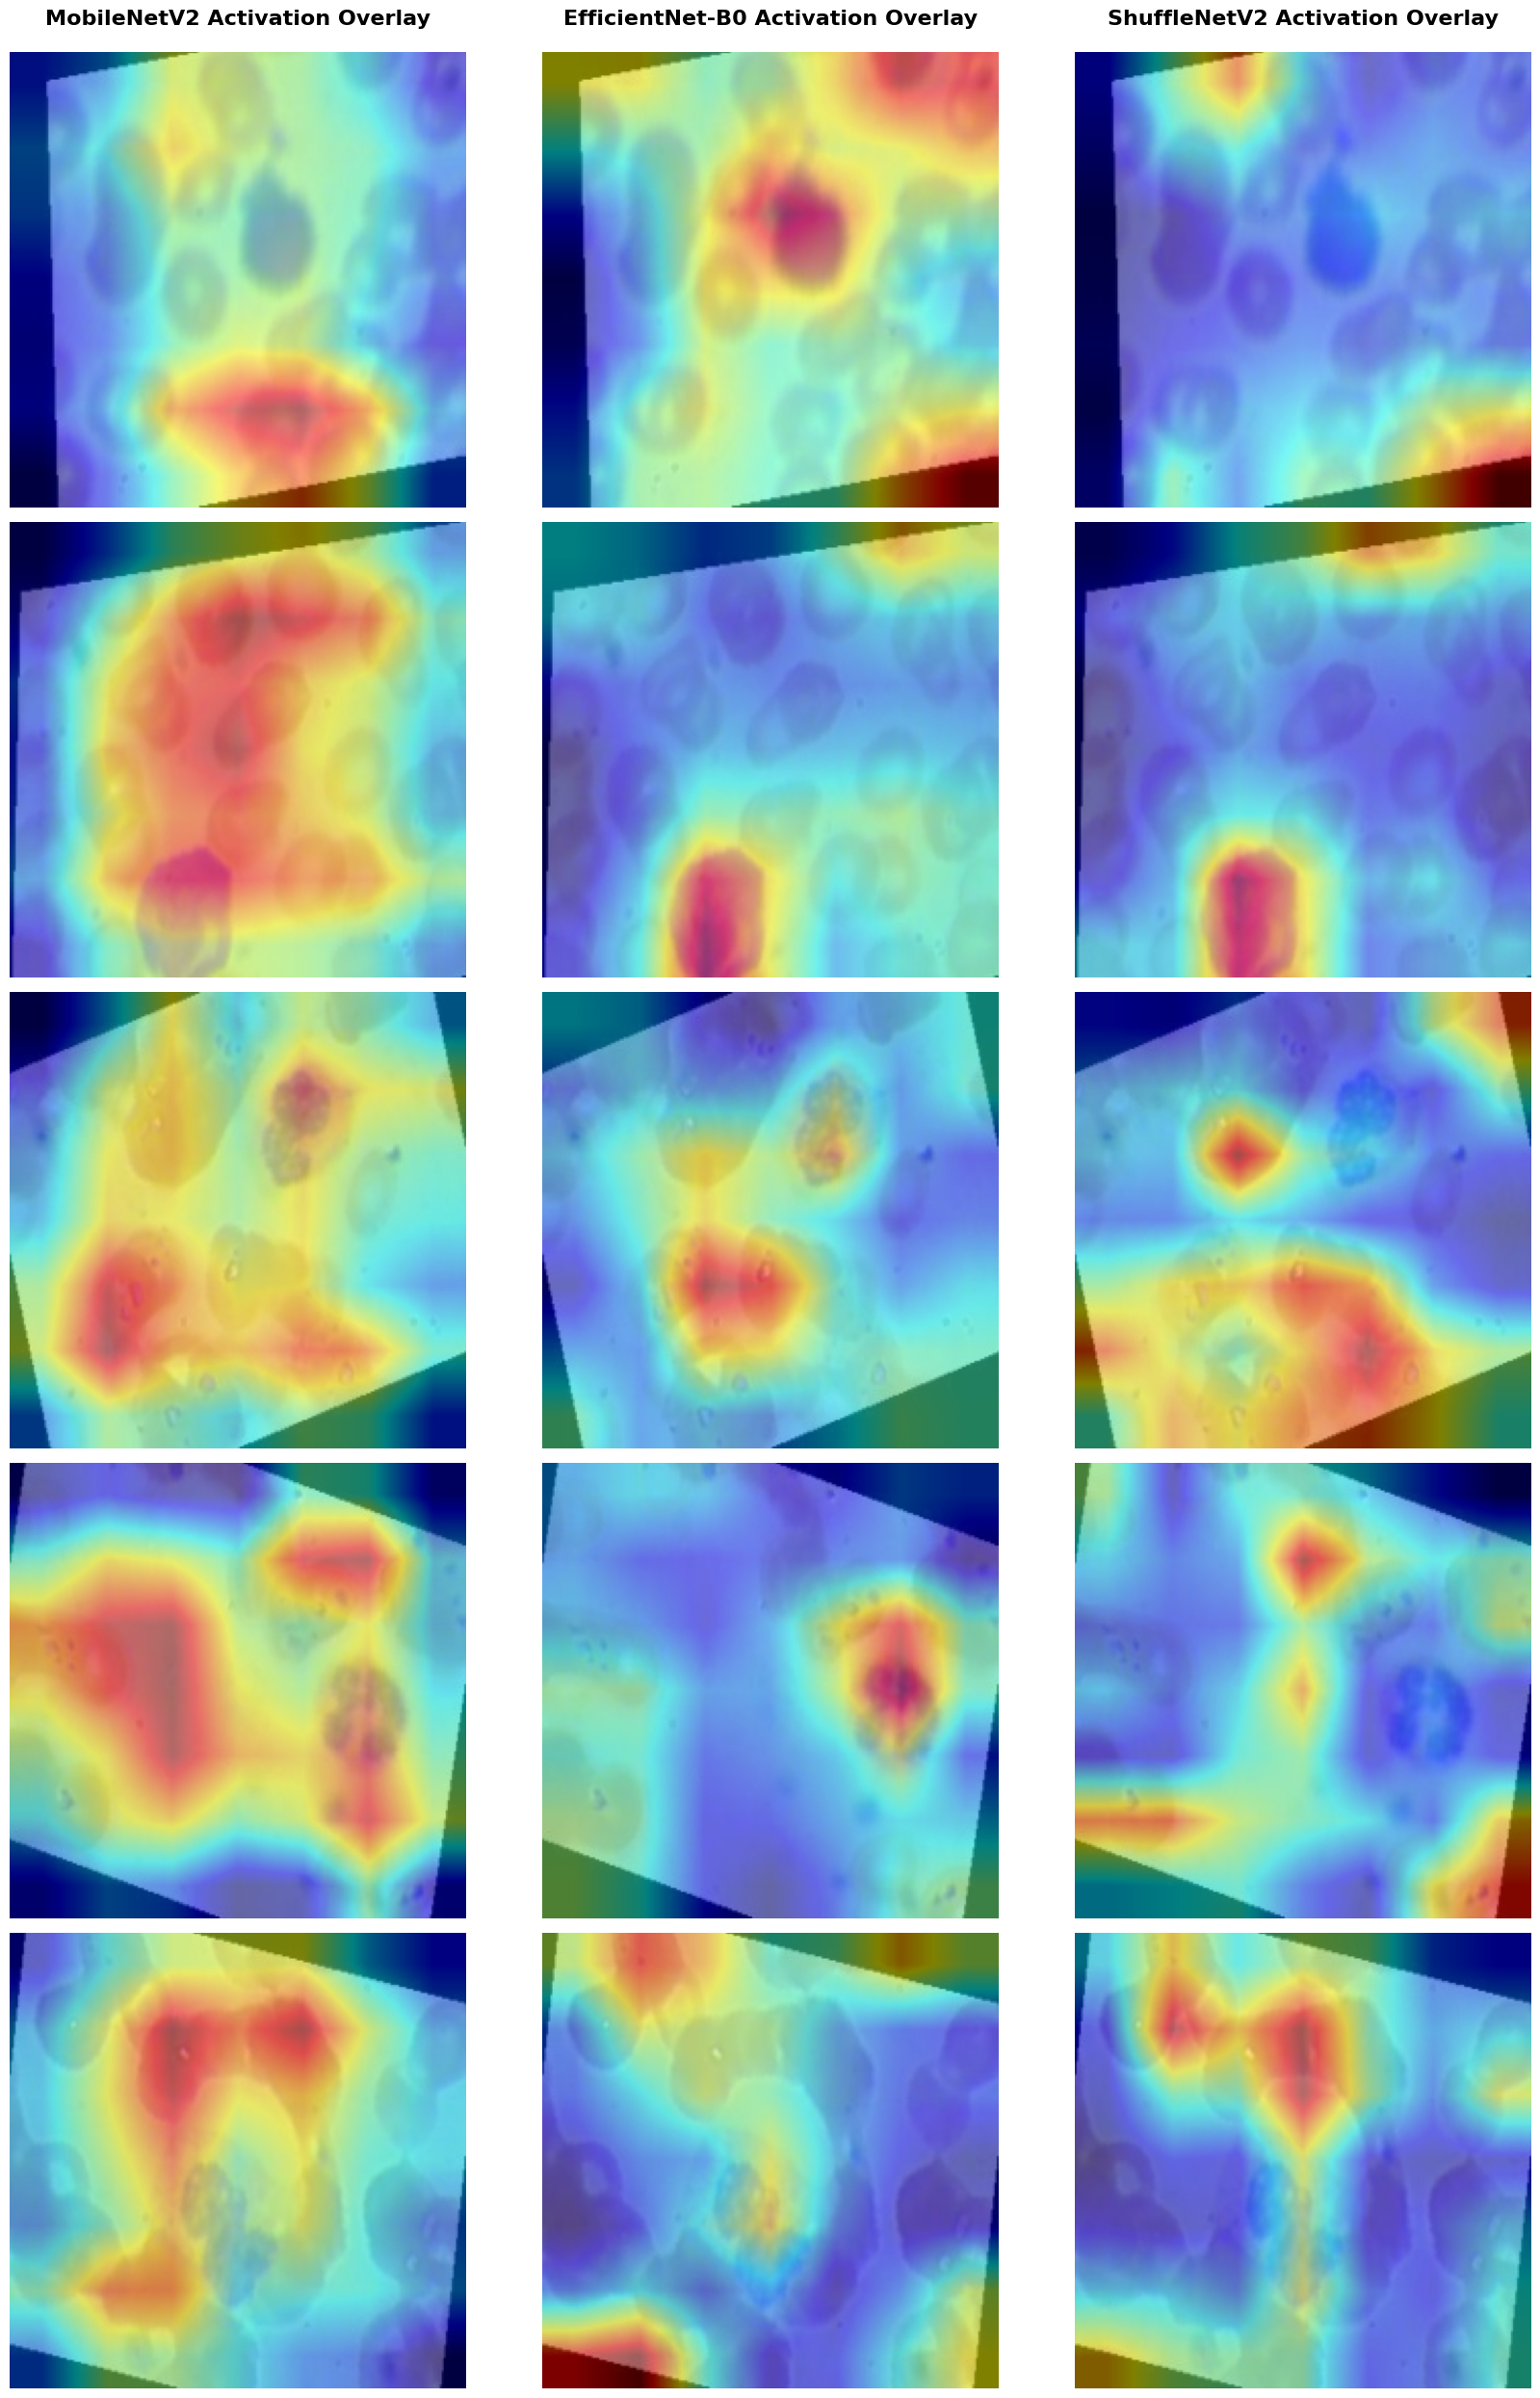

In [14]:
import cv2 # Required for high-quality, efficient bilinear interpolation and overlay blending
from matplotlib.colors import Normalize

def generate_activation_overlay(activation_tensor, original_image_numpy, colormap='jet', alpha=0.5):
    """
    Inputs:
        activation_tensor: Captured hook output, shape (C, H_feat, W_feat)
        original_image_numpy: Denormalized original image, shape (H, W, 3), range [0, 1]
    Outputs:
        final_overlay: (H, W, 3) image with high-res heatmap superimposed.
    """
    # 1. Compute Mean Magnitude Map from Activations
    # Example: (1280, 7, 7) -> (7, 7)
    magnitude_map = torch.mean(activation_tensor, dim=0).cpu().numpy()
    
    # 2. Normalize Magnitude Map to [0, 1] range
    norm = Normalize(vmin=magnitude_map.min(), vmax=magnitude_map.max())
    normalized_magnitude = norm(magnitude_map)
    
    # 3. Bilinear Interpolation to match Target Image Resolution (e.g., 224x224)
    # Target size is 224x224
    interpolated_map = cv2.resize(normalized_magnitude, (224, 224), interpolation=cv2.INTER_LINEAR)
    
    # 4. Generate RGB Heatmap from Interpolated Map
    # Map [0, 1] floats to [0, 255] uint8 for color mapping
    int_heatmap_uint8 = np.uint8(255 * interpolated_map)
    rgb_heatmap = cv2.applyColorMap(int_heatmap_uint8, cv2.COLORMAP_JET)
    rgb_heatmap = cv2.cvtColor(rgb_heatmap, cv2.COLOR_BGR2RGB) # Ensure correct color space
    
    # 5. Prepare Original Image (must match resolution and bit-depth)
    # Current range [0, 1] -> [0, 255] uint8
    image_display_uint8 = np.uint8(255 * original_image_numpy)

    # 6. Final Alpha-Blended Superimposition (Overlay)
    final_overlay = cv2.addWeighted(image_display_uint8, 1 - alpha, rgb_heatmap, alpha, 0)
    
    return final_overlay / 255.0 # Return in [0, 1] range for pyplot


# --- Main Visualization Comparison Loop ---

# Setup Comparison grid: 5 Samples (Rows) x 3 Models (Columns)
fig, axes = plt.subplots(5, 3, figsize=(18, 25))
plt.subplots_adjust(wspace=0.1, hspace=0.3)

# Define precise indices to grab specific, diverse samples from the test loader
# e.g., different cell types or different rotations
sample_indices = [0, 5, 10, 15, 20] 
# (You may need to inspect the 'classes' variable to select relevant diverse indices)

# Grab the first batch to pull samples from
sample_tensor_batch, sample_label_batch = next(iter(test_loader))

# Column headers
model_names = ['MobileNetV2', 'EfficientNet-B0', 'ShuffleNetV2']
for j, name in enumerate(model_names):
    axes[0, j].set_title(f"{name} Activation Overlay", fontsize=16, fontweight='bold', pad=20)

# ImageNet normalization stats used in Cell 2
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# Iterate through 5 distinct samples (ROWS)
for row_idx, data_idx in enumerate(sample_indices):
    
    # Get the specific image tensor (3, 224, 224)
    single_image_tensor = sample_tensor_batch[data_idx]
    
    # Prepare the raw image for display (Denormalize and reshape to HWC)
    img_display = std * single_image_tensor.cpu().numpy().transpose((1, 2, 0)) + mean
    img_display = np.clip(img_display, 0, 1) # Ensure safe range

    # Set row label (optional, can print the class name)
    axes[row_idx, 0].set_ylabel(f"Sample {data_idx}\nClass: {classes[sample_label_batch[data_idx]]}", fontsize=12, fontweight='bold')

    # Iterate through 3 architectures (COLUMNS)
    for col_idx, arch in enumerate(model_names):
        print(f"Generating Overlay: Sample {data_idx} - Model {arch}...")
        
        # 1. Build the specific pre-trained model
        # (Assuming you have run Cell 3 recently to define this function)
        model = build_model(arch, num_classes)
        # 2. Attach the specific hook needed for this architecture (Defined in Cell 6)
        attach_hook(model, arch) 
        
        # 3. Critical Inference Pass (must be unbatched: 1, 3, 224, 224)
        model.eval()
        with torch.no_grad():
            _ = model(single_image_tensor.unsqueeze(0).to(device))
            
        # 4. Extract the captured activation tensor (channels, 7, 7)
        act_tensor = activation['final_conv'].squeeze()
        
        # 5. Call our high-res overlay generator
        final_visualization = generate_activation_overlay(act_tensor, img_display, colormap='jet', alpha=0.5)
        
        # 6. Plot the result in the corresponding subplot
        axes[row_idx, col_idx].imshow(final_visualization)
        axes[row_idx, col_idx].axis('off')

print("\nVisualization complete. Compare which features (nucleus vs granules) each model prioritizes!")
plt.tight_layout()
plt.show()